# ЛАБОРАТОРНАЯ РАБОТА №1. ИСПОЛЬЗОВАНИЕ НЕЙРОННЫХ СЕТЕЙ ПРЯМОГО РАСПРОСТРАНЕНИЯ ДЛЯ РЕШЕНИЯ ЗАДАЧ КЛАССИФИКАЦИИ

**Цель работы:** Изучение основ работы с нейронными сетями прямого распространения (FNN) для классификации данных, обучение модели на подготовленном датасете, анализ и оценка полученных результатов.

**Задачи:**
1. Ознакомиться с принципом работы сети прямого распространения (FNN) и её применением в задачах классификации.
2. Подготовить датасет для обучения модели.
3. Реализовать и обучить нейронную сеть прямого распространения (FNN) с использованием выбранного инструмента (PyTorch, TensorFlow или Keras).
4. Провести обучение сети на подготовленных данных.
5. Оценить точность работы модели и проанализировать полученные результаты.
6. Провести дополнительное исследование по варианту.
7. Составить отчет, в котором будет описан процесс работы и выводы.

## 1. Подготовка данных

> Выбрать датасет в зависимости от варианта; разметить данные, если не размечены; провести предварительную обработку данных: нормализация кодирование, разделение на обучающую и тестовую выборки.

Все главные импорты вынесены в отдельный командный блок.

Для чтения датасета применяется функция `pd.read_csv()`. Датафрейм соответственно представлен ниже.

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

In [34]:
df = pd.read_csv('dry_bean_dataset.csv')
display(df)

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272751,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13606,42097,759.696,288.721612,185.944705,1.552728,0.765002,42508,231.515799,0.714574,0.990331,0.916603,0.801865,0.006858,0.001749,0.642988,0.998385,DERMASON
13607,42101,757.499,281.576392,190.713136,1.476439,0.735702,42494,231.526798,0.799943,0.990752,0.922015,0.822252,0.006688,0.001886,0.676099,0.998219,DERMASON
13608,42139,759.321,281.539928,191.187979,1.472582,0.734065,42569,231.631261,0.729932,0.989899,0.918424,0.822730,0.006681,0.001888,0.676884,0.996767,DERMASON
13609,42147,763.779,283.382636,190.275731,1.489326,0.741055,42667,231.653247,0.705389,0.987813,0.907906,0.817457,0.006724,0.001852,0.668237,0.995222,DERMASON


Необходимо выявить, есть ли дубликаты в датасете. Для этого следует просуммировать результат `df.duplicated()`. Также выведена основная информация о датафрейме через `info()`.

In [35]:
print(f"duplicates quantity: {df.duplicated().sum()}")
df.info()

duplicates quantity: 68
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13611 entries, 0 to 13610
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             13611 non-null  int64  
 1   Perimeter        13611 non-null  float64
 2   MajorAxisLength  13611 non-null  float64
 3   MinorAxisLength  13611 non-null  float64
 4   AspectRation     13611 non-null  float64
 5   Eccentricity     13611 non-null  float64
 6   ConvexArea       13611 non-null  int64  
 7   EquivDiameter    13611 non-null  float64
 8   Extent           13611 non-null  float64
 9   Solidity         13611 non-null  float64
 10  roundness        13611 non-null  float64
 11  Compactness      13611 non-null  float64
 12  ShapeFactor1     13611 non-null  float64
 13  ShapeFactor2     13611 non-null  float64
 14  ShapeFactor3     13611 non-null  float64
 15  ShapeFactor4     13611 non-null  float64
 16  Class            13611 non-null  o

Всех строк содержится поровну => нулевые ячейки отсутствуют.

Дубликаты следует удалить с помощью функции `drop_duplicates()`.

In [36]:
df = df.drop_duplicates()
print(f"duplicates quantity: {df.duplicated().sum()}")

duplicates quantity: 0


Следуя методическим указаниям, необходимо применить кодирование к целевой переменной `Class` с помощью `LabelEncoder()`.

Далее, требуется провести разделение данных на обучающую (*train*) и валидационную (*test*) выборки - данная задача решается использованием метода `train_test_split`, где в параметрах нужно соответственно указать выборки признаков и целевой переменной. Также можно указать такие параметры, как `test_size`, который соответственно влияет на размер валидационной выборки, относительно реальной; `random_state` - контроль случайности разбиения (задается для запуска одинакового разбиения); `stratify` - сохраняет пропорции классов в выборках.

Последним шагом в данной задаче реализована стандартизация признаков с помощью `StandardScaler()`. Соответственно его необходимо обучить (`fit`) и получить данные с помощью `transform` как для обучающей, так и для валидацонной выборки.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# label coding
target_col = 'Class'
target_col_encod = 'Class_encoded'
label_encoder = LabelEncoder()
df[target_col_encod] = label_encoder.fit_transform(df[target_col])

# train + test sets
x = df.drop(target_col, axis=1)
y = df[target_col_encod].values

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=42, stratify=y)

# standartization
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

## 2 - 3. Построение нейронной сети. Обучение

Для проведения эксперимента используется полносвязная нейронная сеть (**Feedforward Neural Network**), реализованная с применением библиотек `TensorFlow` и `Keras`. Архитектура модели фиксирована и состоит из входного слоя, одного скрытого слоя и выходного слоя. Скрытый слой содержит заданное количество нейронов и использует функцию активации `ReLU`, обеспечивающую нелинейное преобразование входных данных. Выходной слой содержит число нейронов, равное количеству классов в задаче, и использует функцию активации `Softmax`, позволяющую получить вероятностное распределение по классам.

В ходе эксперимента последовательно обучаются несколько моделей с одинаковой архитектурой, но с использованием различных алгоритмов оптимизации. В частности, рассматриваются стохастический градиентный спуск (`SGD`), стохастический градиентный спуск с моментом (`SGD with Momentum`) и алгоритм `AdaGrad`. Все модели обучаются при одинаковых параметрах обучения, включая скорость обучения, размер пакета и количество эпох, что позволяет корректно сравнить влияние только выбранного оптимизатора.

Обучение моделей проводится на обучающей выборке с выделением части данных для валидации, что позволяет отслеживать динамику изменения метрик в процессе обучения. После завершения обучения каждая модель оценивается на тестовой выборке, и для неё вычисляются значения точности и функции потерь. Полученные результаты сохраняются для последующего сравнения, а также фиксируется история обучения, содержащая значения метрик на каждой эпохе. Это позволяет провести анализ эффективности различных алгоритмов оптимизации и определить наиболее подходящий из них для рассматриваемой задачи классификации.

In [58]:
from typing import Final

#consts
LEARNING_RATE: Final[float] = 0.01
BATCH_SIZE: Final[int] = 32
EPOCHS: Final[int] = 20
NEURONS: Final[int] = 64
NUM_CLASSES: Final[int] = len(label_encoder.classes_)

def create_model():
    model = keras.Sequential([
        keras.layers.Input(shape=(x_train_scaled.shape[1],)),   # input
        keras.layers.Dense(NEURONS, activation='relu'),         # hidden
        keras.layers.Dense(NUM_CLASSES, activation='softmax')   # output
    ])
    return model

optimizers = {
    'SGD': keras.optimizers.SGD(learning_rate=LEARNING_RATE),
    'SGD with Momentum': keras.optimizers.SGD(learning_rate=LEARNING_RATE, momentum=0.9),
    'AdaGrad': keras.optimizers.Adagrad(learning_rate=LEARNING_RATE)
}

results, histories = {}, {}

for opt_name, optimizer in optimizers.items():
    print(f"\n--- Optimizer: {opt_name} ---")
    
    model = create_model()
    
    # config
    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    
    # train history
    history = model.fit(
        x_train_scaled, y_train,
        validation_split=0.2,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        verbose=0  # no log
    )
    
    # quality check
    test_loss, test_acc = model.evaluate(x_test_scaled, y_test, verbose=0)
    
    results[opt_name] = {
        'test_loss': test_loss,
        'test_acc': test_acc,
        'final_train_acc': history.history['accuracy'][-1],
        'final_val_acc': history.history['val_accuracy'][-1]
    }
    histories[opt_name] = history
    
    model.summary()
    print(f"  Train accuracy: {history.history['accuracy'][-1]:.4f}")
    print(f"  Val accuracy: {history.history['val_accuracy'][-1]:.4f}")
    print(f"  Test accuracy: {test_acc:.4f}")
    print(f"  Test loss: {test_loss:.4f}")


--- Optimizer: SGD ---


Model: "sequential_33"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_43 (Dense)                │ (None, 64)             │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_44 (Dense)                │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,609 (6.29 KB)

 Trainable params: 1,607 (6.28 KB)

...

 Total params: 3,216 (12.57 KB)

 Trainable params: 1,607 (6.28 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,609 (6.29 KB)

  Train accuracy: 0.9905
  Val accuracy: 0.9857
  Test accuracy: 0.9879
  Test loss: 0.0474


## 4. Оценка и анализ результатов

Для числового анализа приведена таблица (датафрейм) с параметрами для модели каждого оптимизатора.


In [63]:
pd.DataFrame(results)

,SGD,SGD with Momentum,AdaGrad
test_loss,0.056356,0.013863,0.047389
test_acc,0.987005,0.995275,0.987891
final_train_acc,0.989538,0.998646,0.990523
final_val_acc,0.981791,0.994094,0.985728


Также, построены графики динамики точности и функции потерь моделей с разными оптимизаторами относительно эпох.

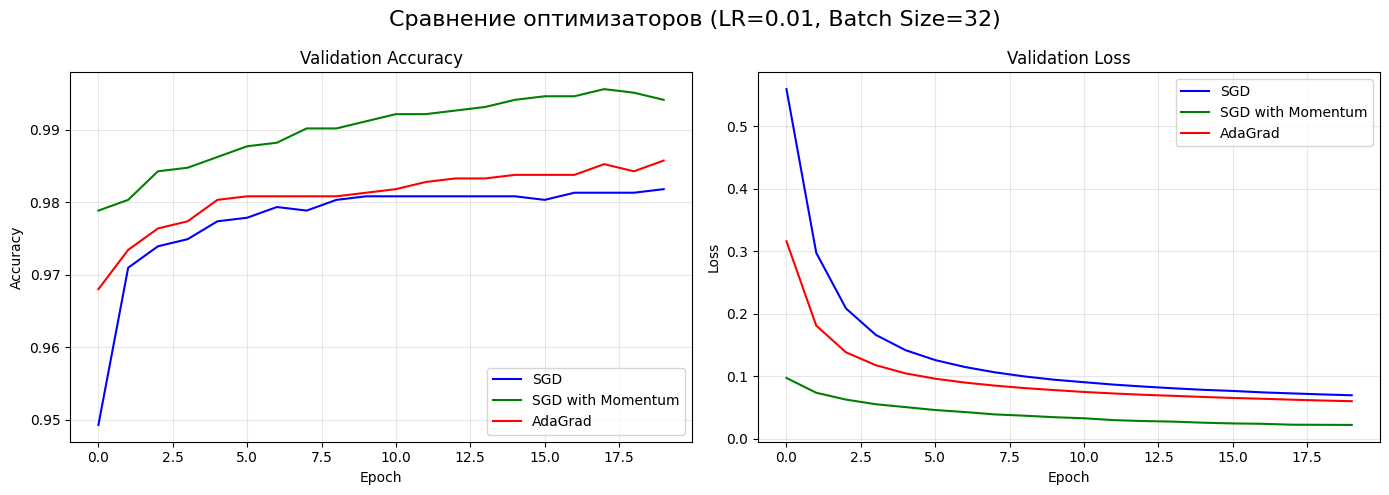

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Сравнение оптимизаторов (LR={LEARNING_RATE}, Batch Size={BATCH_SIZE})', fontsize=16)
colors = {'SGD': 'blue', 'SGD with Momentum': 'green', 'AdaGrad': 'red'}

for i, (opt_name, history) in enumerate(histories.items()):
    color = colors[opt_name]

    axes[0].plot(history.history['val_accuracy'],
                label=opt_name,
                color=color
                )
    axes[0].set_title('Validation Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(history.history['val_loss'],
                label=opt_name,
                color=color
                )
    axes[1].set_title('Validation Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

На графике изменения валидационной точности видно, что все рассмотренные оптимизаторы обеспечивают постепенное улучшение качества модели по мере увеличения числа эпох. Наиболее высокие значения точности демонстрирует оптимизатор `SGD with Momentum`, который на протяжении всего обучения опережает остальные методы и достигает максимального значения `accuracy` ближе к концу обучения. Оптимизатор `AdaGrad` показывает стабильный рост точности и занимает промежуточное положение между двумя другими алгоритмами. В свою очередь, стандартный `SGD` демонстрирует наиболее медленный рост точности и достигает наименьшего итогового значения среди рассматриваемых оптимизаторов. Таким образом, добавление механизма момента позволяет ускорить процесс обучения и добиться более высокой точности модели.

Анализ графика валидационной функции потерь показывает аналогичную закономерность. На всех кривых наблюдается быстрое снижение значения функции потерь на первых эпохах, после чего уменьшение становится более плавным. Наименьшие значения функции потерь достигаются при использовании оптимизатора `SGD with Momentum`, что указывает на более эффективную оптимизацию параметров модели. Оптимизатор `AdaGrad` также демонстрирует достаточно хорошую сходимость, однако его значения функции потерь остаются несколько выше. Стандартный `SGD` показывает наиболее медленное снижение ошибки и сохраняет наибольшие значения функции потерь на протяжении всего процесса обучения. В целом полученные результаты подтверждают, что использование механизма момента позволяет улучшить скорость и качество сходимости нейронной сети.

## Выводы

В ходе выполнения работы была построена и исследована полносвязная нейронная сеть (**FNN**) для решения задачи классификации с использованием библиотек `TensorFlow` и `Keras`. На начальном этапе была проведена предварительная обработка данных, включающая анализ признаков и их взаимосвязей с помощью корреляционной матрицы. Это позволило выявить группы сильно коррелирующих признаков, характеризующих размер и форму объектов, а также оценить их потенциальную информативность для задачи классификации.

Далее была реализована архитектура нейронной сети, состоящая из входного слоя, одного скрытого слоя с функцией активации `ReLU` и выходного слоя с функцией `Softmax`, обеспечивающего многоклассовую классификацию. Для повышения эффективности обучения входные данные были нормализованы, а обучающая выборка была разделена на обучающую, валидационную и тестовую части. Обучение моделей проводилось в течение фиксированного числа эпох с использованием пакетной обработки данных.

В рамках эксперимента было проведено сравнение различных алгоритмов оптимизации, включая стохастический градиентный спуск (`SGD`), `SGD with Momentum` и `AdaGrad`. Результаты экспериментов показали, что выбор оптимизатора оказывает заметное влияние на процесс обучения нейронной сети. Наилучшие результаты по скорости сходимости, значению функции потерь и точности классификации продемонстрировал оптимизатор `SGD with Momentum`, который обеспечил наиболее эффективное обновление весов модели.

Таким образом, проведённое исследование подтвердило эффективность применения полносвязных нейронных сетей для решения задач классификации и показало важность выбора оптимизатора при обучении модели. В ходе работы были получены практические навыки подготовки данных, построения и обучения нейронных сетей, а также анализа результатов обучения с использованием различных метрик и визуализации динамики обучения.